In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer dataset
cancer = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Convert target to B/M to match your practical
df['diagnosis'] = ['M' if x == 0 else 'B' for x in cancer.target]

print(df.head())
print(df.columns.tolist())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

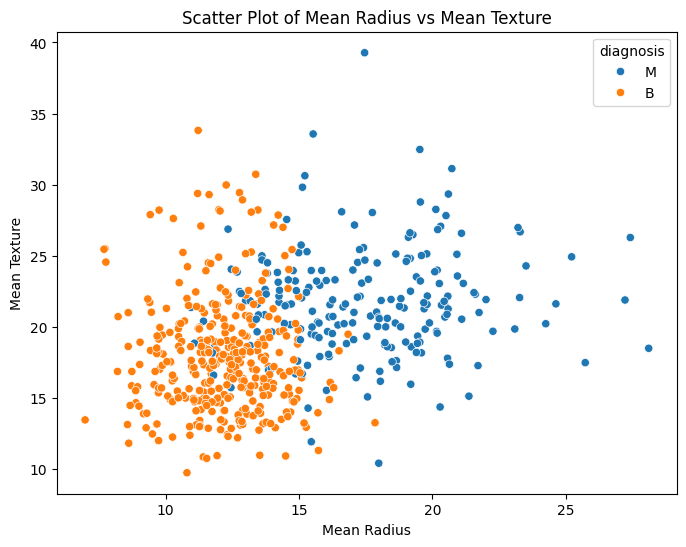

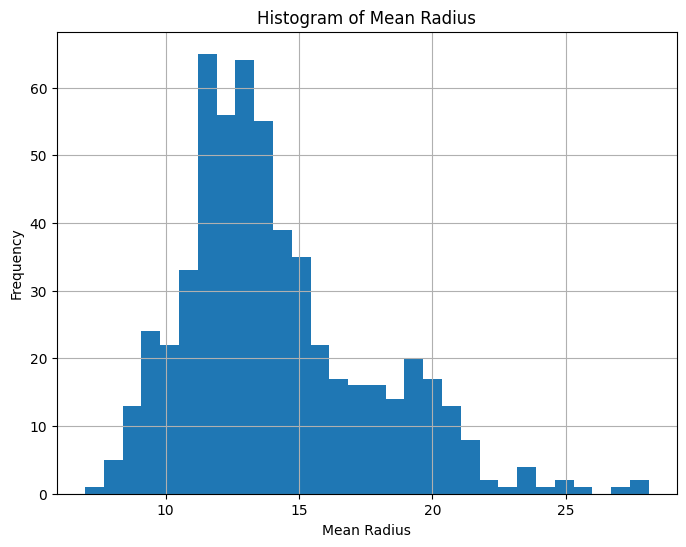

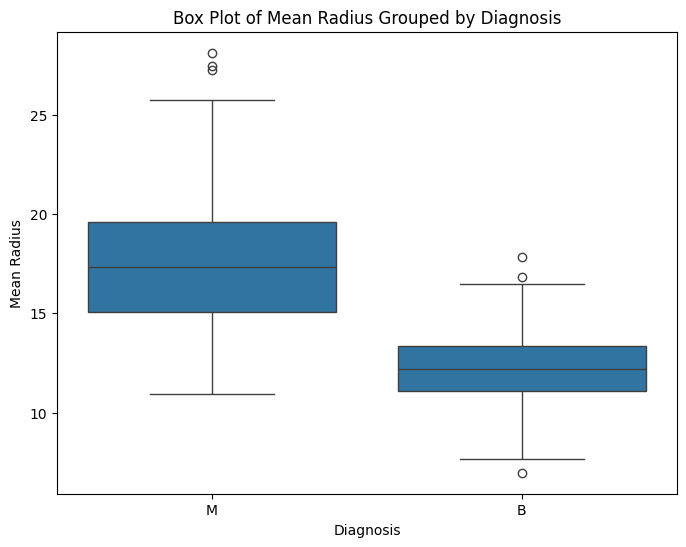

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# (i) Scatter Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='mean radius',
    y='mean texture',
    hue='diagnosis',
    data=df
)

plt.title("Scatter Plot of Mean Radius vs Mean Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.show()


# (ii) Histogram
plt.figure(figsize=(8, 6))

df['mean radius'].hist(bins=30)

plt.title("Histogram of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()


# (iii) Box Plot
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='diagnosis',
    y='mean radius',
    data=df
)

plt.title("Box Plot of Mean Radius Grouped by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")
plt.show()

In [10]:
# Implementing Naïve Bayes Classification

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Remove rows containing missing values
df_cleaned = df.dropna()

# Define features (X) and target (y)
X = df_cleaned.drop(['diagnosis'], axis=1)
y = df_cleaned['diagnosis']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Initialize Naïve Bayes classifier
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

# Predict on the test set
y_pred = nb.predict(X_test)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        71
           M       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy: 0.9737
